# Spike Sorting in Spyglass (pipeline version 1)

This notebook runs the **Spyglass spike sorting pipeline version 1 (V1)** directly on
ephys data that has **already been inserted into the Spyglass database** from the
Wood/Dudchenko NWB files.

This is different from the standalone `Pipeline_H8000.ipynb` (and the other notebooks in
this folder), which run [`spikeinterface`](https://spikeinterface.readthedocs.io/) directly
on raw Open Ephys folders and never touch Spyglass. Here, the raw recording lives in the
`Raw` table of the database, and every stage of sorting is stored and tracked as a
DataJoint table.

The spike data that came in during the original NWB conversion was *imported* from the NWB
`units` table into `ImportedSpikeSorting`. At the end of this notebook we fetch **both** the
new Spyglass-sorted result and that original imported result, and plot them side by side so
the path to each is explicit.

Following the structure of `Pipeline_H8000.ipynb`, all of the choices you would normally
change are collected in a single **"parameters set manually"** cell near the top.

## Connect to the database

We load the DataJoint config (which holds the database connection info) and import the
Spyglass modules. Importing `spyglass.common` is what actually opens the connection.

In [1]:
import datajoint as dj
import numpy as np
import matplotlib.pyplot as plt

# Load config for database connection info
dj_local_conf_path = "/Users/pauladkisson/Documents/CatalystNeuro/Spyglass/spyglass/dj_local_conf.json"
dj.config.load(dj_local_conf_path)
dj.config["enable_python_native_blobs"] = True

# General Spyglass imports (importing common connects to the database)
import spyglass.common as sgc
import spyglass.spikesorting.v1 as sgs
from spyglass.spikesorting.spikesorting_merge import SpikeSortingOutput
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename

/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-06-16 10:21:27,035][INFO]: DataJoint is configured from /Users/pauladkisson/Documents/CatalystNeuro/Spyglass/spyglass/dj_local_conf.json
[2026-06-16 10:21:27,430][INFO]: DataJoint 0.14.9 connected to root@localhost:3306
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Parameters set manually

Everything you might want to change for a different session, shank, or sorter lives here.

> The `mountainsort5` sorter must be installed in this environment: `pip install mountainsort5`.

In [2]:
### Parameters set manually ###

# Session: the NWB copy that lives in the database (note the trailing underscore)
nwb_file_name = get_nwb_copy_filename("H3022-210806.nwb")  # -> "H3022-210806_.nwb"

# Which shank (sort group) and which epoch (interval) to sort
sort_group_id = 0
interval_list_name = "01"  # first wake epoch for this session

# Lab team that owns the sorting (any unique name)
team_name = "Wood/Dudchenko Lab"

# Pipeline parameters (these names refer to rows in the corresponding parameter tables)
preproc_param_name = "default"
artifact_param_name = "default"
sorter = "mountainsort5"        # requires: pip install mountainsort5
sorter_param_name = "default"

# Automatic-curation parameters
waveform_param_name = "default_not_whitened"
metric_param_name = "franklab_default"
metric_curation_param_name = "default"

## Inspect the session

Before sorting, confirm the session is in the database and look at the electrode layout and
the interval we are going to sort. The raw ephys for this session lives in the `Raw` table.

In [3]:
sgc.Session() & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,subject_id,institution_name,lab_name,session_id,session_description,session_start_time,timestamps_reference_time,experiment_description
H3022-210806_.nwb,H3022,University of Edinburgh,Wood/Dudchenko lab,210806,"Exploration, sleep and cue rotation",2021-08-06 11:34:07,2021-08-06 11:34:07,Basic properties of the head-direction system


In [4]:
# Electrode / shank layout for this session
sgc.Electrode & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,electrode_group_name electrode group name from NWBFile,electrode_id the unique number for this electrode,probe_id a unique ID for this probe & dynamic config,probe_shank unique shank number within probe.,probe_electrode electrode ID from ShanksElectrode.name,region_id,name unique label for each contact,original_reference_electrode the configured reference electrode for this electrode,x the x coordinate of the electrode position in the brain,y the y coordinate of the electrode position in the brain,z the z coordinate of the electrode position in the brain,filtering description of the signal filtering,impedance electrode impedance,"bad_channel if electrode is ""good"" or ""bad"" as observed during recording",x_warped x coordinate of electrode position warped to common template brain,y_warped y coordinate of electrode position warped to common template brain,z_warped z coordinate of electrode position warped to common template brain,contacts label of electrode contacts used for a bipolar signal - current workaround
H3022-210806_.nwb,probe1_shank1,0,Cambridge Neurotech H6b probe,1,0,1,0,-1,nan,nan,nan,unfiltered,nan,False,0.0,0.0,0.0,
H3022-210806_.nwb,probe1_shank1,1,Cambridge Neurotech H6b probe,1,1,1,1,-1,nan,nan,nan,unfiltered,nan,False,0.0,0.0,0.0,
H3022-210806_.nwb,probe1_shank1,2,Cambridge Neurotech H6b probe,1,2,1,2,-1,nan,nan,nan,unfiltered,nan,False,0.0,0.0,0.0,
H3022-210806_.nwb,probe1_shank1,3,Cambridge Neurotech H6b probe,1,3,1,3,-1,nan,nan,nan,unfiltered,nan,False,0.0,0.0,0.0,
H3022-210806_.nwb,probe1_shank1,4,Cambridge Neurotech H6b probe,1,4,1,4,-1,nan,nan,nan,unfiltered,nan,False,0.0,0.0,0.0,
H3022-210806_.nwb,probe1_shank1,5,Cambridge Neurotech H6b probe,1,5,1,5,-1,nan,nan,nan,unfiltered,nan,False,0.0,0.0,0.0,
H3022-210806_.nwb,probe1_shank1,6,Cambridge Neurotech H6b probe,1,6,1,6,-1,nan,nan,nan,unfiltered,nan,False,0.0,0.0,0.0,
H3022-210806_.nwb,probe1_shank1,7,Cambridge Neurotech H6b probe,1,7,1,7,-1,nan,nan,nan,unfiltered,nan,False,0.0,0.0,0.0,
H3022-210806_.nwb,probe1_shank1,8,Cambridge Neurotech H6b probe,1,8,1,8,-1,nan,nan,nan,unfiltered,nan,False,0.0,0.0,0.0,
H3022-210806_.nwb,probe1_shank1,9,Cambridge Neurotech H6b probe,1,9,1,9,-1,nan,nan,nan,unfiltered,nan,False,0.0,0.0,0.0,


In [5]:
# Available intervals -- confirm that interval_list_name exists
sgc.IntervalList & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,valid_times numpy array with start/end times for each interval,pipeline type of interval list
H3022-210806_.nwb,01,=BLOB=,
H3022-210806_.nwb,02,=BLOB=,
H3022-210806_.nwb,03,=BLOB=,
H3022-210806_.nwb,04,=BLOB=,
H3022-210806_.nwb,c1260a11-da2e-4efb-bedb-e830d3d33a66,=BLOB=,spikesorting_artifact_v1
H3022-210806_.nwb,compass 1 valid times,=BLOB=,
H3022-210806_.nwb,ee510a80-dc56-4062-bfb1-c44555ce89b0,=BLOB=,spikesorting_recording_v1
H3022-210806_.nwb,imported lfp 0 valid times,=BLOB=,imported_lfp
H3022-210806_.nwb,imported pseudoemg valid times,=BLOB=,imported_pseudoemg
H3022-210806_.nwb,pos 0 valid times,=BLOB=,position


## Lab team

All spike sorting results are linked to a team in the `LabTeam` table. Create it if it does
not already exist.

In [6]:
if not (sgc.LabTeam() & {"team_name": team_name}):
    sgc.LabTeam().create_new_team(
        team_name=team_name,
        team_members=[],
        team_description="Wood/Dudchenko lab spike sorting",
    )

## Define sort groups

Electrodes are grouped for sorting by the shank they sit on; electrodes in the same sort
group are sorted together.

Spyglass ships `SortGroup.set_group_by_shank`, but it assumes the electrode-group names are
numeric (it sorts them with `int(...)`). In this dataset the groups are named like
`probe1_shank1`, so that helper raises `ValueError: invalid literal for int()`. We therefore
build the sort groups manually below: one sort group per electrode group (shank), omitting
bad channels, with the reference taken from each shank's `original_reference_electrode`
(here `-1`, i.e. no reference). This session uses a single-shank probe, so there is one sort
group (`sort_group_id = 0`).

In [7]:
# Build sort groups manually (one per electrode group / shank), omitting bad channels.
def set_sort_groups_by_electrode_group(nwb_file_name):
    electrodes = (
        sgc.Electrode & {"nwb_file_name": nwb_file_name} & {"bad_channel": "False"}
    ).fetch()
    electrode_group_names = sorted(np.unique(electrodes["electrode_group_name"]))

    sort_group_keys, sort_group_electrode_keys = [], []
    for sort_group_id, electrode_group_name in enumerate(electrode_group_names):
        in_group = electrodes["electrode_group_name"] == electrode_group_name
        reference_ids = np.unique(electrodes["original_reference_electrode"][in_group])
        assert len(reference_ids) == 1, (
            f"electrode group {electrode_group_name} has multiple reference electrodes"
        )
        sort_group_keys.append(
            {
                "nwb_file_name": nwb_file_name,
                "sort_group_id": sort_group_id,
                "sort_reference_electrode_id": int(reference_ids[0]),
            }
        )
        sort_group_electrode_keys.extend(
            {
                "nwb_file_name": nwb_file_name,
                "sort_group_id": sort_group_id,
                "electrode_group_name": electrode_group_name,
                "electrode_id": int(electrode_id),
            }
            for electrode_id in electrodes["electrode_id"][in_group]
        )

    sgs.SortGroup.insert(sort_group_keys, skip_duplicates=True)
    sgs.SortGroup.SortGroupElectrode.insert(
        sort_group_electrode_keys, skip_duplicates=True
    )


set_sort_groups_by_electrode_group(nwb_file_name)
sgs.SortGroup & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,sort_group_id,sort_reference_electrode_id the electrode to use for referencing
H3022-210806_.nwb,0,-1


## Select and extract the recording

`SpikeSortingRecordingSelection` combines a sort group + interval + preprocessing
parameters and generates a unique `recording_id`. Populating `SpikeSortingRecording` then
filters and references the recording (isolating the spike band) and stores the result as
NWB.

In [8]:
key = {
    "nwb_file_name": nwb_file_name,
    "sort_group_id": sort_group_id,
    "preproc_param_name": preproc_param_name,
    "interval_list_name": interval_list_name,
    "team_name": team_name,
}
sgs.SpikeSortingRecordingSelection.insert_selection(key)

ssr_pk = (sgs.SpikeSortingRecordingSelection & key).proj()
sgs.SpikeSortingRecording.populate(ssr_pk)

# Re-fetch the full key so it now carries the generated recording_id
key = (sgs.SpikeSortingRecordingSelection & key).fetch1()
sgs.SpikeSortingRecording & {"recording_id": key["recording_id"]}

[10:21:30][WARNING] Spyglass: Similar row(s) already inserted.


recording_id,analysis_file_name name of the file,object_id Object ID for the processed recording in NWB file,electrodes_id Object ID for the processed electrodes,hash Hash of the NWB file
ee510a80-dc56-4062-bfb1-c44555ce89b0,H3022-210806_UKCXI1UYEQ.nwb,65df8331-3e0d-4a37-ae79-0e0ffbf3fda5,3e8a37db-0284-43c7-89f3-e52602da8a2f,4c947af98b8715c109414c1b5d6fff55


## Artifact detection

Large transients across all channels (e.g. movement or licking artifacts) can confound
sorting. `ArtifactDetection` finds those periods and writes the artifact-free intervals to
`IntervalList`, keyed by a generated `artifact_id`.

In [9]:
sgs.ArtifactDetectionSelection.insert_selection(
    {"recording_id": key["recording_id"], "artifact_param_name": artifact_param_name}
)
sgs.ArtifactDetection.populate()

sgs.ArtifactDetection & {"recording_id": key["recording_id"]}

[10:21:30][WARNING] Spyglass: Similar row(s) already inserted.


[10:21:30][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.


artifact_id
c1260a11-da2e-4efb-bedb-e830d3d33a66


## Run spike sorting

We pair the prepared recording with a sorter and its parameters in `SpikeSortingSelection`,
then populate `SpikeSorting`. The interval we sort over is the artifact-free interval
produced above (referenced by its `artifact_id`).

`SpikeSorterParameters.insert_default()` makes sure a `"default"` parameter set exists for
every available sorter, including `mountainsort5`.

In [10]:
sgs.SpikeSorterParameters.insert_default()

sorting_key = {
    "recording_id": key["recording_id"],
    "sorter": sorter,
    "nwb_file_name": nwb_file_name,
    "interval_list_name": str(
        (sgs.ArtifactDetectionSelection & {"recording_id": key["recording_id"]}).fetch1(
            "artifact_id"
        )
    ),
    "sorter_param_name": sorter_param_name,
}
sgs.SpikeSortingSelection.insert_selection(sorting_key)

sss_pk = (sgs.SpikeSortingSelection & sorting_key).proj()
sgs.SpikeSorting.populate(sss_pk)

sgs.SpikeSorting & sorting_key

[10:21:30][INFO] Spyglass: Similar row(s) already inserted.
[10:21:30][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.


sorting_id,analysis_file_name name of the file,object_id Object ID for the sorting in NWB file,"time_of_sort in Unix time, to the nearest second"
7bba3012-1453-404f-b8fd-4d78386e704f,H3022-210806_CDANLFXQQV.nwb,2edfe9e8-7ec1-41da-ab32-a2fbdca189d5,1781626325


## Curation

Sorters are imperfect, so the raw output is normally curated. We register the raw sort in
`CurationV1` as `curation_id = 0`; this is a complete, usable sorting result and is what we
carry forward to the merge table below.

Spyglass also offers **automatic metric-based curation** (`MetricCuration`), which computes
quality metrics (SNR, ISI violations, nearest-neighbor noise overlap, ...) and applies
label/merge rules. We do **not** run it here: its NWB writer
(`_write_metric_curation_to_nwb`) raises `Cannot infer dtype of empty list` whenever **no
unit** triggers a labeling rule. With the `default` parameters the only rule is
`nn_noise_overlap > 0.1`, and no unit in this recording exceeds it, so every label is empty
and the write fails. To use metric curation, choose metric/label parameters under which at
least one unit is labeled.

In [11]:
sorting_id = (sgs.SpikeSortingSelection & {"recording_id": key["recording_id"]}).fetch1(
    "sorting_id"
)

# Register the raw sorting as the first curation (curation_id = 0)
sgs.CurationV1.insert_curation(sorting_id=sorting_id, description="initial curation")
sgs.CurationV1 & {"sorting_id": sorting_id}

[10:21:32][INFO] Spyglass: Writing new NWB file H3022-210806_XYA51K5IBT.nwb
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:738: MissingRequiredBuildWarning: NWBFile 'root' is missing required value for attribute 'source_script_file_name'.
  warnings.warn(msg, MissingRequiredBuildWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:738: MissingRequired

sorting_id,curation_id,parent_curation_id,analysis_file_name name of the file,object_id,merges_applied,description
7bba3012-1453-404f-b8fd-4d78386e704f,0,-1,H3022-210806_SOT0T8WP8V.nwb,01058cdb-881f-47ed-8524-9ee4a32a59da,0,initial curation
7bba3012-1453-404f-b8fd-4d78386e704f,1,-1,H3022-210806_0YQXMJWMTF.nwb,3d8af7c0-965a-490e-91f5-1a7eb6fb902f,0,initial curation
7bba3012-1453-404f-b8fd-4d78386e704f,2,-1,H3022-210806_XYA51K5IBT.nwb,efaa0183-7bcb-455b-9a70-1d2eec666d93,0,initial curation


## Manual curation (optional, not run here)

Spyglass also supports manual curation through [FigURL](https://github.com/flatironinstitute/figurl).
This requires a kachery sharing setup (see `02_Data_Sync.ipynb` in the Spyglass notebooks)
and will not work on the demo server, so we do not run it here. The relevant tables are
`FigURLCurationSelection` and `FigURLCuration`; their labels/merges would be inserted back
into `CurationV1` as a further curation, exactly like the metric curation above.

## Insert into the `SpikeSortingOutput` merge table

To make a sorting available to downstream pipelines, insert the chosen curation into the
`SpikeSortingOutput` merge table. We use `curation_id = 0` (the raw sort registered above).

In [12]:
curation_key = sss_pk.fetch1("KEY")
curation_key["curation_id"] = 0
merge_insert_key = (sgs.CurationV1 & curation_key).fetch("KEY", as_dict=True)
SpikeSortingOutput.insert(merge_insert_key, part_name="CurationV1")

SpikeSortingOutput.merge_view()

[10:21:33][INFO] Spyglass: Key already in part CurationV1: {'sorting_id': UUID('7bba3012-1453-404f-b8fd-4d78386e704f'), 'curation_id': 0}


*merge_id      *source        *sorting_id    *curation_id   *nwb_file_name
+------------+ +------------+ +------------+ +------------+ +------------+
045b9965-9cea- ImportedSpikeS None           0              H4819-220929_.
048a2f6c-b630- ImportedSpikeS None           0              H4827-221210_.
0b425267-f081- ImportedSpikeS None           0              H4822-221023_.
0f0b203d-5d95- ImportedSpikeS None           0              H3026-211004_2
13ae1d88-f0d2- ImportedSpikeS None           0              H3029-230510_.
16b94a6e-1155- ImportedSpikeS None           0              H4825-221124_.
18293671-bb23- ImportedSpikeS None           0              H3015-210416_1
1a5d7b3f-fe03- CurationV1     7bba3012-1453- 0              None          
1aa93663-216a- ImportedSpikeS None           0              H4826-221203_.
26a370c8-12ff- ImportedSpikeS None           0              H3023-210812_.
26c458e7-add2- ImportedSpikeS None           0              H3019-210618_1
30e9d5bf-aa2c- ImportedSp

## Fetch the new Spyglass V1 sorting

The result we just produced lives in the **`CurationV1`** part of `SpikeSortingOutput`. We
can find its `merge_id` by restricting on the things we set above (`sorter`, `curation_id`).
We load the sorting as a `spikeinterface` object and draw a spike raster.

[10:21:33][WARNING] Spyglass: V0 requires artifact restrict. Ignoring restrict_by_artifact
[2026-06-16 10:21:33,573][WARNING]: Skipped checksum for file with hash: 582bbcc2-7ced-18ea-49e9-45419659b88d, and path: /Users/pauladkisson/Documents/CatalystNeuro/DudchenkoConv/Spyglass/analysis/H3022-210806/H3022-210806_UKCXI1UYEQ.nwb


Spyglass V1 merge id(s): [{'merge_id': UUID('1a5d7b3f-fe03-3660-27ce-6fa5044ae53d')}]


/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
[10:21:34][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)


Text(0.5, 1.0, 'Spyglass V1 sorting (mountainsort5) -- sort group 0, epoch 01')

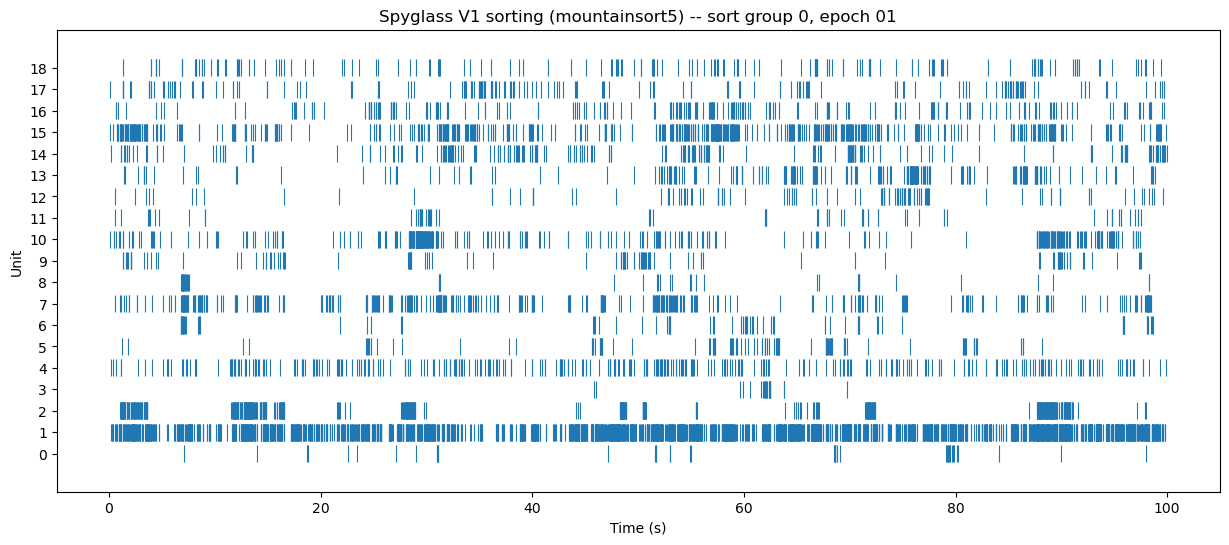

In [13]:
v1_merge_ids = SpikeSortingOutput().get_restricted_merge_ids(
    {"nwb_file_name": nwb_file_name, "sorter": sorter, "curation_id": 0},
    as_dict=True,
)
print("Spyglass V1 merge id(s):", v1_merge_ids)

# Load the sorting as a spikeinterface object; get_unit_spike_train(..., return_times=True)
# returns spike times in seconds.
v1_sorting = sgs.SpikeSorting.get_sorting(sorting_key)
v1_unit_ids = v1_sorting.get_unit_ids()
v1_spike_times = [
    v1_sorting.get_unit_spike_train(unit_id, return_times=True) for unit_id in v1_unit_ids
]

raster_start_time = 0.0
raster_stop_time = 100.0


def window(spike_times_list, start, stop):
    return [
        times[(times >= start) & (times <= stop)] for times in spike_times_list
    ]


plt.figure(figsize=(15, 6))
ax = plt.gca()
ax.eventplot(
    window(v1_spike_times, raster_start_time, raster_stop_time),
    linelengths=0.8,
    linewidths=0.8,
    colors="tab:blue",
)
ax.set_yticks(range(len(v1_unit_ids)))
ax.set_ylabel("Unit")
ax.set_xlabel("Time (s)")
ax.set_title(f"Spyglass V1 sorting ({sorter}) -- sort group {sort_group_id}, epoch {interval_list_name}")

## Comparing to the original imported sorting

The sorting that came in during the original NWB conversion is **not** gone -- it lives in a
**different part table** of the same merge table:

| Source | Merge-table part | How it got there |
| --- | --- | --- |
| This notebook (Spyglass V1) | `SpikeSortingOutput.CurationV1` | We ran the V1 pipeline above. Has a `sorter` and `curation_id`. |
| Original conversion | `SpikeSortingOutput.ImportedSpikeSorting` | Imported from the NWB `units` table. No `sorter` field. |

Because they are separate rows (each with its own `merge_id`), restricting on
`sorter="mountainsort5"` only ever returns the new one -- the two never get conflated.
The original imported sorting is most easily reached through the pre-existing
`SortedSpikesGroup` named `"all_units"` (the same one used in `example_notebook.ipynb`).

In [14]:
# The original imported sorting also lives in SpikeSortingOutput, as a separate part table:
sgs.ImportedSpikeSorting & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,object_id
H3022-210806_.nwb,00aaa3fa-0c60-4842-9b62-9c3a16290210


Text(0.5, 1.0, 'Original imported sorting (all_units)')

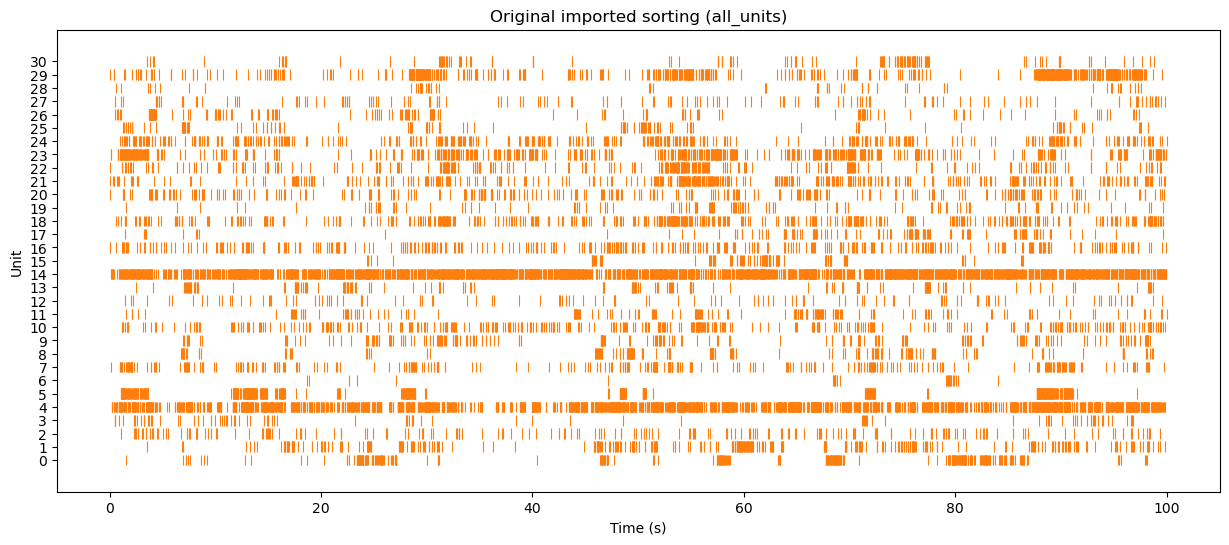

In [15]:
# Fetch the original imported spike data via the existing SortedSpikesGroup
imported_group_key = (
    SortedSpikesGroup
    & {"nwb_file_name": nwb_file_name, "sorted_spikes_group_name": "all_units"}
).fetch1("KEY")
imported_spike_data, imported_unit_ids = SortedSpikesGroup().fetch_spike_data(
    imported_group_key, return_unit_ids=True
)
imported_spike_data = [np.asarray(times) for times in imported_spike_data]

plt.figure(figsize=(15, 6))
ax = plt.gca()
ax.eventplot(
    window(imported_spike_data, raster_start_time, raster_stop_time),
    linelengths=0.8,
    linewidths=0.8,
    colors="tab:orange",
)
ax.set_yticks(range(len(imported_unit_ids)))
ax.set_ylabel("Unit")
ax.set_xlabel("Time (s)")
ax.set_title("Original imported sorting (all_units)")

## Side-by-side comparison

Finally, plot both rasters over the same time window. The top panel is the sorting we just
produced with Spyglass + `mountainsort5`; the bottom panel is the original sorting imported
during conversion. They are queried through the same merge table but via different routes,
as described above.

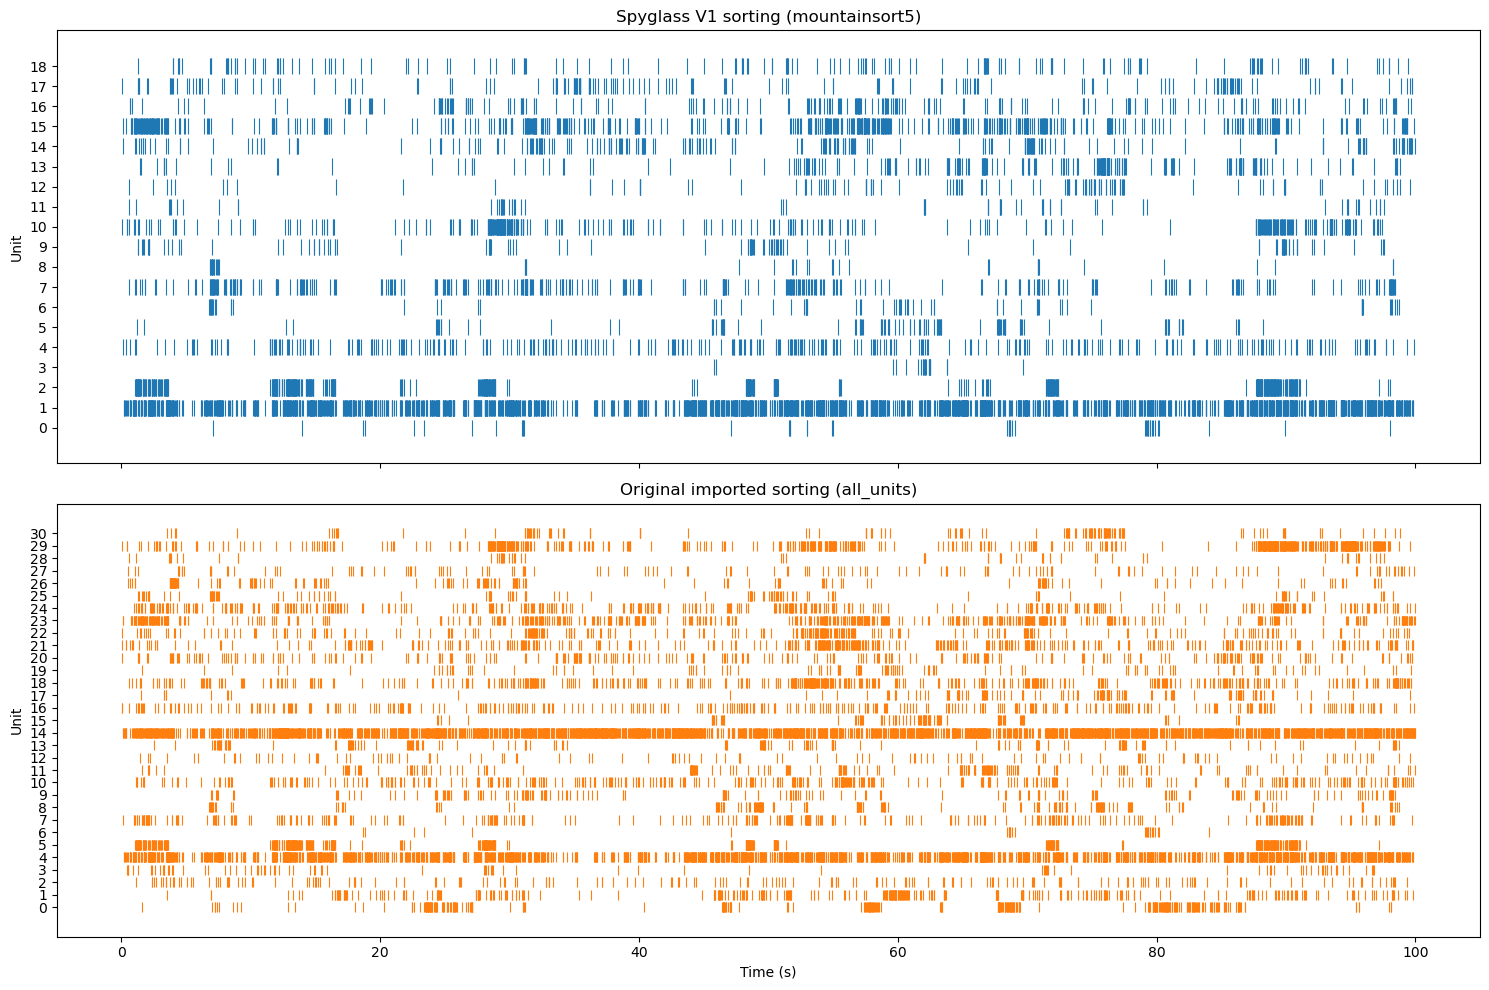

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].eventplot(
    window(v1_spike_times, raster_start_time, raster_stop_time),
    linelengths=0.8,
    linewidths=0.8,
    colors="tab:blue",
)
axes[0].set_yticks(range(len(v1_unit_ids)))
axes[0].set_ylabel("Unit")
axes[0].set_title(f"Spyglass V1 sorting ({sorter})")

axes[1].eventplot(
    window(imported_spike_data, raster_start_time, raster_stop_time),
    linelengths=0.8,
    linewidths=0.8,
    colors="tab:orange",
)
axes[1].set_yticks(range(len(imported_unit_ids)))
axes[1].set_ylabel("Unit")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Original imported sorting (all_units)")

plt.tight_layout()